# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
!pip install tab-transformer-pytorch

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader

file_path = 'train2.csv'
data2 = pd.read_csv(file_path)

data2 = data2.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

In [ ]:
# 결측치 삭제

data2 = data2.dropna(subset=['Credit_Score'])

data2 = data2.dropna(subset=['Monthly_Balance'])

In [ ]:
numeric_data = data2.select_dtypes(include=np.number)

corr = numeric_data.corr()['Credit_Score'].abs()

print(corr.sort_values(ascending=False))

Credit_Score                1.000000
Credit_Mix                  0.233432
Num_of_Delayed_Payment      0.208403
Changed_Credit_Limit        0.199085
Num_Bank_Accounts           0.180232
Interest_Rate               0.116087
Credit_History_Age          0.109680
Num_Credit_Card             0.109149
Annual_Income               0.102961
Delay_from_due_date         0.101599
Monthly_Inhand_Salary       0.100955
Amount_invested_monthly     0.078636
Total_EMI_per_month         0.075080
Num_Credit_Inquiries        0.074981
Monthly_Balance             0.062084
Age                         0.058380
Num_of_Loan                 0.055554
Month                       0.033415
Outstanding_Debt            0.032550
Credit_Utilization_Ratio    0.011893
Name: Credit_Score, dtype: float64


In [ ]:
data2.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income,EMI_to_Salary,Delay_per_Loan
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.500000,33.316340,6.949840,10.536540,8.045535,5.368820,5.533570,14.53208,3.532880,21.08141,...,221.220460,1.403190,3.898967,3.774458,2.776630,5.845133,1.353460,0.060653,0.029782,3.914475
std,2.291299,10.764812,4.309542,0.790548,0.800100,2.593314,2.067098,8.74133,2.446356,14.80456,...,99.680716,0.693378,1.627409,0.817564,1.856069,0.555431,0.764913,0.087416,0.031430,3.396939
min,0.000000,14.000000,0.000000,8.854655,5.719149,0.000000,0.000000,1.00000,0.000000,0.00000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.007730,0.000000,0.000003,0.000000,0.000000
25%,1.750000,24.000000,3.000000,9.870136,7.394858,3.000000,4.000000,7.00000,2.000000,10.00000,...,144.000000,1.000000,3.410120,3.365885,1.000000,5.593283,1.000000,0.009572,0.012127,2.000000
50%,3.500000,33.000000,7.000000,10.518692,8.038159,5.000000,5.000000,13.00000,3.000000,18.00000,...,219.000000,2.000000,4.211569,3.832039,3.000000,5.813729,2.000000,0.028249,0.024407,3.000000
75%,5.250000,42.000000,11.000000,11.180029,8.692610,7.000000,7.000000,20.00000,5.000000,28.00000,...,302.000000,2.000000,4.999861,4.280766,5.000000,6.140349,2.000000,0.069713,0.040322,4.500000
max,7.000000,56.000000,14.000000,12.100647,9.629421,11.000000,11.000000,34.00000,9.000000,62.00000,...,404.000000,2.000000,7.484427,6.075785,5.000000,7.077440,2.000000,0.683157,1.976969,23.000000


In [ ]:
# 파생변수 추가

data2['Debt_to_Income'] = (
    data2['Outstanding_Debt'] /
    (data2['Annual_Income'] + 1)
)

data2['EMI_to_Salary'] = (
    data2['Total_EMI_per_month'] /
    (data2['Monthly_Inhand_Salary'] + 1)
)

data2['Delay_per_Loan'] = (
    data2['Num_of_Delayed_Payment'] /
    (data2['Num_of_Loan'] + 1)
)

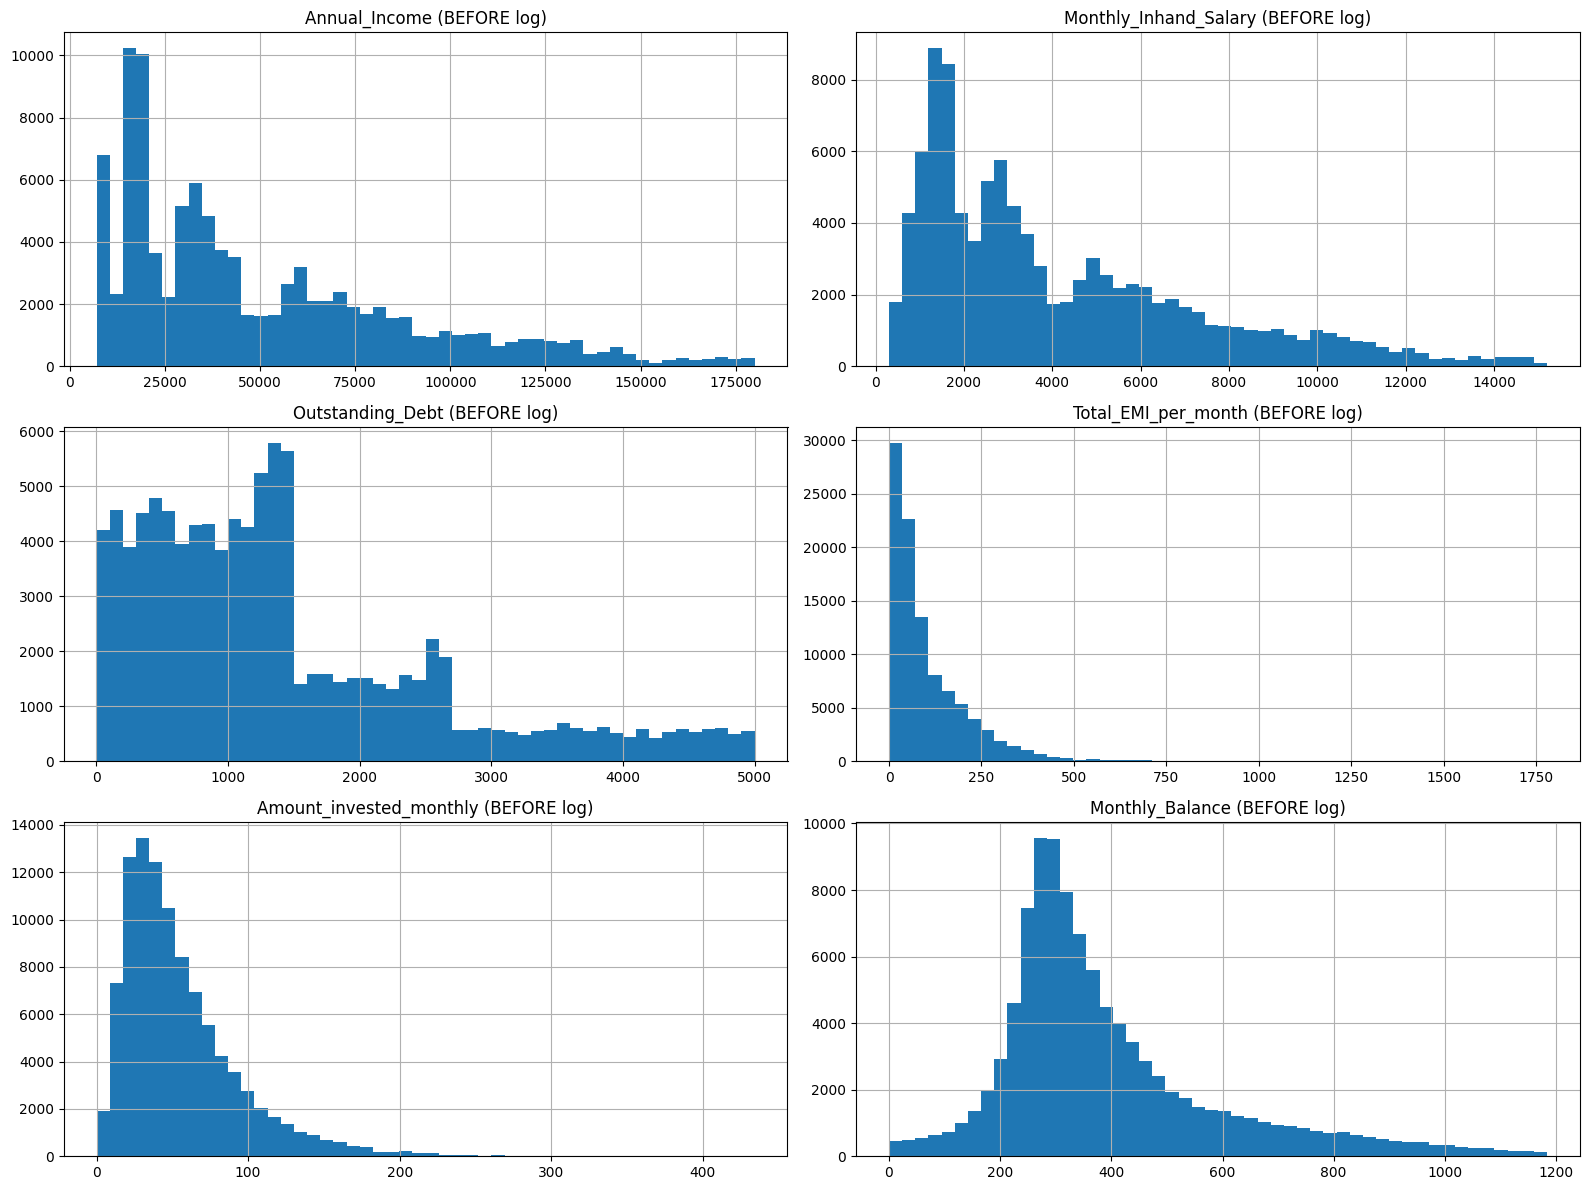

In [ ]:
# 값 분포도 확인(로그변환의 유무)

import matplotlib.pyplot as plt

log_cols = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(log_cols):

    plt.subplot(3, 2, i + 1)

    data2[col].hist(bins=50)

    plt.title(f'{col} (BEFORE log)')

plt.tight_layout()
plt.show()

In [ ]:
# 로그변환

log_cols = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in log_cols:
    data2[col] = np.log1p(data2[col])

In [ ]:
# 의미없는 컬럼 제거
data2 = data2.drop(columns=['Type_of_Loan'])

KeyError: "['Type_of_Loan'] not found in axis"

In [ ]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  int64  
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int64  
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    100000 non-null  int64  
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  int64  
 13  Credit_Mix                100000 non-null  ob

In [ ]:
# 타겟
target_col = 'Credit_Score'

# 범주형 / 연속형 구분
cat_cols = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

num_cols = [
    'Month','Age','Annual_Income','Monthly_Inhand_Salary',
    'Num_Bank_Accounts','Num_Credit_Card','Interest_Rate',
    'Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment',
    'Changed_Credit_Limit','Num_Credit_Inquiries','Outstanding_Debt',
    'Credit_Utilization_Ratio','Credit_History_Age',
    'Total_EMI_per_month','Amount_invested_monthly',
    'Monthly_Balance','Debt_to_Income','EMI_to_Salary','Delay_per_Loan'
]

In [ ]:
label_encoders = {}

# 범주형
for col in cat_cols:
    le = LabelEncoder()
    data2[col] = le.fit_transform(data2[col])
    label_encoders[col] = le

# 타겟 encoding (중요)
target_le = LabelEncoder()
data2[target_col] = target_le.fit_transform(data2[target_col])

In [ ]:
# 정답값 분리
X = data2[cat_cols + num_cols]
y = data2[target_col]

#데이터 8:2 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 스케일링 진행
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
#텐서변환

X_train_cat = torch.tensor(X_train[cat_cols].values, dtype=torch.long)
X_test_cat = torch.tensor(X_test[cat_cols].values, dtype=torch.long)

X_train_num = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_test_num = torch.tensor(X_test[num_cols].values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from tab_transformer_pytorch import TabTransformer

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

# DataLoader 생성
batch_size = 1024

train_dataset = TensorDataset(
    X_train_cat,
    X_train_num,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_cat,
    X_test_num,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

# TabTransformer 모델 생성
categories = tuple(
    int(data2[col].nunique()) for col in cat_cols
)

model = TabTransformer(
    categories=categories,
    num_continuous=len(num_cols),

    dim=16,
    dim_out=len(target_le.classes_), # 클래스 개수
    depth=3,
    heads=4,

    attn_dropout=0.1,
    ff_dropout=0.1,

    mlp_hidden_mults=(4, 2),
    mlp_act=nn.ReLU(),
)

# 모델 GPU 이동
model = model.to(device)

# Loss / Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# 학습
num_epochs = 50

for epoch in range(num_epochs):
    # 학습모드
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x_cat, x_num, y in train_loader:

        # GPU 이동
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        # forward
        y_pred = model(x_cat, x_num)

        # loss
        loss = criterion(y_pred, y)

        # backward
        loss.backward()

        # update
        optimizer.step()

        # loss 누적
        train_loss += loss.item()

        # accuracy 계산
        preds = torch.argmax(y_pred, dim=1)

        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    train_acc = train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # 평가모드
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x_cat, x_num, y in test_loader:

            # GPU 이동
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y = y.to(device)

            # 예측
            val_pred = model(x_cat, x_num)

            # loss
            loss = criterion(val_pred, y)

            val_loss += loss.item()

            # accuracy
            preds = torch.argmax(val_pred, dim=1)

            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss / len(test_loader)

    # 출력
    print(
    f"Epoch [{epoch+1}/{num_epochs}] | "
    f"Train Loss: {train_loss:.4f} | "
    f"Train Acc: {train_acc:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Val Acc: {val_acc:.4f}"
    )

사용 장치: cuda
Epoch [1/50] | Train Loss: 0.7568 | Train Acc: 0.6413 | Val Loss: 0.7102 | Val Acc: 0.6770
Epoch [2/50] | Train Loss: 0.6908 | Train Acc: 0.6823 | Val Loss: 0.6836 | Val Acc: 0.6838
Epoch [3/50] | Train Loss: 0.6756 | Train Acc: 0.6903 | Val Loss: 0.6747 | Val Acc: 0.6910
Epoch [4/50] | Train Loss: 0.6700 | Train Acc: 0.6934 | Val Loss: 0.6739 | Val Acc: 0.6918
Epoch [5/50] | Train Loss: 0.6659 | Train Acc: 0.6949 | Val Loss: 0.6665 | Val Acc: 0.6967
Epoch [6/50] | Train Loss: 0.6574 | Train Acc: 0.6971 | Val Loss: 0.6573 | Val Acc: 0.7024
Epoch [7/50] | Train Loss: 0.6547 | Train Acc: 0.6991 | Val Loss: 0.6576 | Val Acc: 0.6972
Epoch [8/50] | Train Loss: 0.6484 | Train Acc: 0.7026 | Val Loss: 0.6511 | Val Acc: 0.7009
Epoch [9/50] | Train Loss: 0.6443 | Train Acc: 0.7039 | Val Loss: 0.6500 | Val Acc: 0.7027
Epoch [10/50] | Train Loss: 0.6401 | Train Acc: 0.7058 | Val Loss: 0.6463 | Val Acc: 0.7067
Epoch [11/50] | Train Loss: 0.6353 | Train Acc: 0.7079 | Val Loss: 0.6434 | V